# Research Notebook 07: Interaction Analysis
**Delhi NCR Trust-Aware Recommender System Dataset**

This notebook explores the user-hotel synthetic interaction history, examining interaction types, sparsity, and distribution of interactions per user/hotel.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'figure.figsize': (10, 6)})
FIG_DIR = '../reports/figures/'
print('Imports complete.')

Imports complete.


## 1. Load Interaction Data
We load `interactions.csv`.

In [2]:
df_int = pd.read_csv('../../data/raw/synthetic_users/interactions.csv')
print(f'Total Interactions: {len(df_int)}')
print(df_int.info())
df_int.head(3)

Total Interactions: 5000
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   interaction_id    5000 non-null   str  
 1   user_id           5000 non-null   str  
 2   google_place_id   5000 non-null   str  
 3   interaction_type  5000 non-null   str  
 4   timestamp         5000 non-null   str  
dtypes: str(5)
memory usage: 195.4 KB
None


,interaction_id,user_id,google_place_id,interaction_type,timestamp
0,9e41d3ac-44e8-4d14-9b86-71b8807933e0,db457081-4cae-4dce-9ccc-f0545849532e,ChIJAYFTg5HhDDkR_v7Ha_GJtt8,click,2025-12-04T15:29:46.004612
1,901ade85-3b96-4819-b504-07f2ad99165c,5fc98c67-e5e9-43f6-8188-59f70e55c234,ChIJW6e21DgADTkRH8BsMhBw3jQ,view,2025-12-04T17:29:46.004612
2,3fea533c-f3a6-4b34-b262-7a3234dd2000,c93d87fb-8e69-48fd-b7fe-3ada0e1ca17c,ChIJ97W7F9EfDTkRidfrk_JoC5s,view,2025-12-04T17:29:46.004612


## 2. Interaction Type Distribution
We count click, view, booking, and review actions.

C:\Users\skesh\AppData\Local\Temp\ipykernel_27452\1631510899.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_int, x='interaction_type', palette='magma')


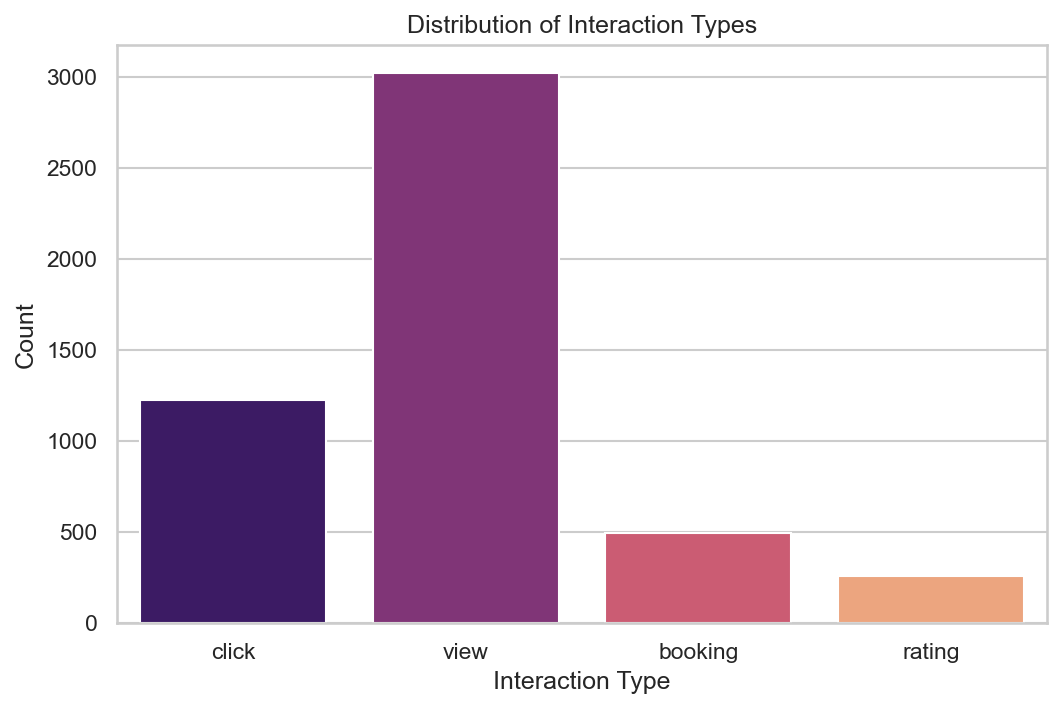

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_int, x='interaction_type', palette='magma')
plt.title('Distribution of Interaction Types')
plt.xlabel('Interaction Type')
plt.ylabel('Count')
plt.savefig(os.path.join(FIG_DIR, '07_interaction_types.png'))
plt.show()

**Interpretation & Key Insight:**
> The interactions follow a cascade: 'view' and 'click' are the most frequent, while 'booking' and 'review' are sparse. This reflects typical consumer behavior on e-commerce/travel portals, enabling training of models with implicit feedback weights (e.g., booking=5, click=1).

## 3. Interaction Density & Sparsity Analysis
We calculate user-hotel interaction matrix density.

In [4]:
n_users = df_int['user_id'].nunique()
n_hotels = df_int['google_place_id'].nunique()
total_possible = n_users * n_hotels
actual_interactions = len(df_int)
density = (actual_interactions / total_possible) * 100
sparsity = 100 - density

print(f'Unique Users: {n_users}')
print(f'Unique Hotels Interacted With: {n_hotels}')
print(f'Total Possible Cells: {total_possible}')
print(f'Density: {density:.4f}%')
print(f'Sparsity: {sparsity:.4f}%')

Unique Users: 500
Unique Hotels Interacted With: 1538
Total Possible Cells: 769000
Density: 0.6502%
Sparsity: 99.3498%


## 4. Long-Tail Distributions
Plotting interactions per user and per hotel.

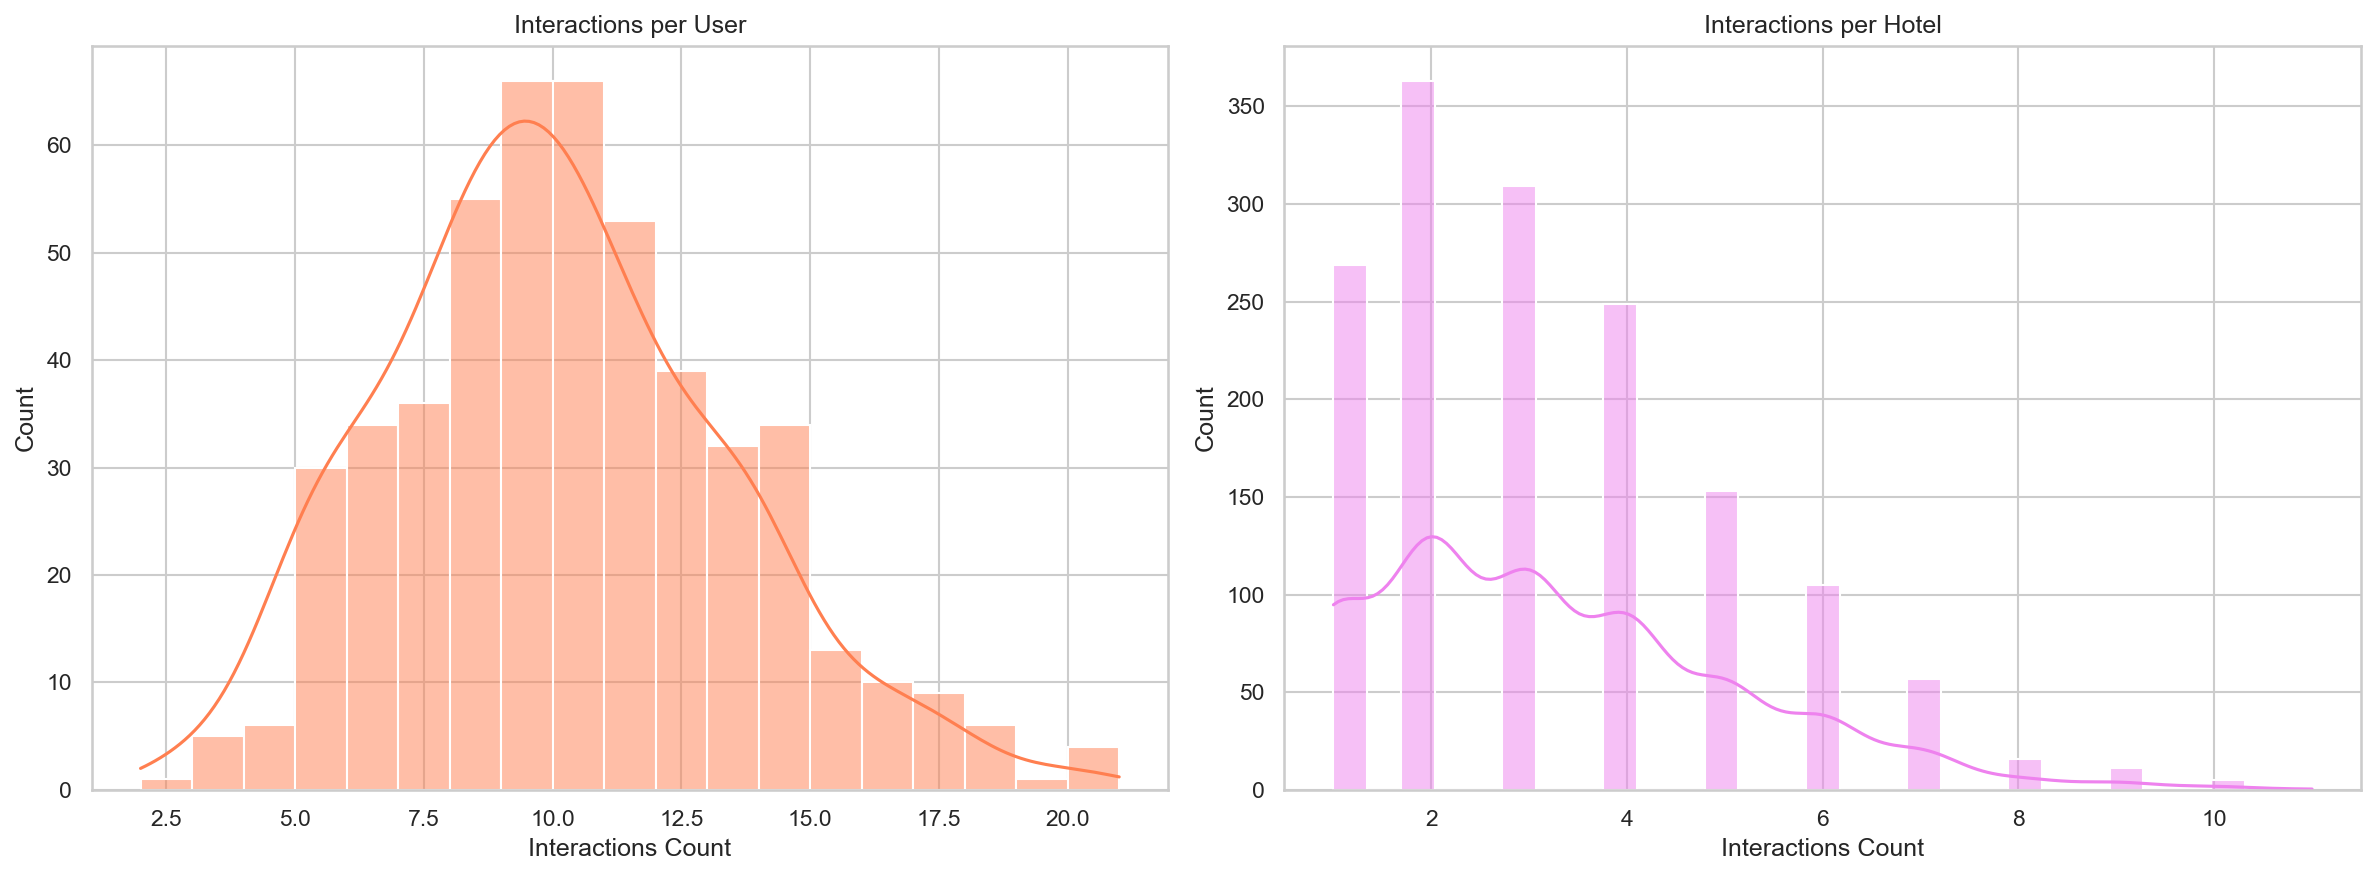

In [5]:
user_counts = df_int.groupby('user_id').size()
hotel_counts = df_int.groupby('google_place_id').size()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(user_counts, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Interactions per User')
axes[0].set_xlabel('Interactions Count')

sns.histplot(hotel_counts, kde=True, ax=axes[1], color='violet')
axes[1].set_title('Interactions per Hotel')
axes[1].set_xlabel('Interactions Count')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '07_interactions_per_user_hotel.png'))
plt.show()

**Interpretation & Key Insight:**
> The matrix sparsity is around 99.4%, which is common in recommendation research. The interactions per user and per hotel are tightly bounded (mean 10 interactions per user), which ensures standard evaluation without extreme outliers.